In [79]:
import pandas as pd

df = pd.read_csv(
    "/content/Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [80]:
df.shape

(9994, 21)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [82]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

quality_report

,Column,Data Type,Missing Values,Unique Values
Row ID,Row ID,int64,0,9994
Order ID,Order ID,object,0,5009
Order Date,Order Date,object,0,1237
Ship Date,Ship Date,object,0,1334
Ship Mode,Ship Mode,object,0,4
Customer ID,Customer ID,object,0,793
Customer Name,Customer Name,object,0,793
Segment,Segment,object,0,3
Country,Country,object,0,1
City,City,object,0,531


In [85]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [86]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [87]:
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [88]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [89]:
print("Negative Sales:", (df["Sales"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Discount below 0:", (df["Discount"] < 0).sum())
print("Discount above 1:", (df["Discount"] > 1).sum())

Negative Sales: 0
Zero Quantity: 0
Negative Quantity: 0
Discount below 0: 0
Discount above 1: 0


In [90]:
import numpy as np

# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Calculate descriptive statistics
statistics = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Row ID,4997.500000,4997.5000,1.00,2885.163629
Postal Code,55190.379428,56430.5000,10035.00,32063.693350
Sales,229.858001,54.4900,12.96,623.245101
Quantity,3.789574,3.0000,3.00,2.225110
Discount,0.156203,0.2000,0.00,0.206452
Profit,28.656896,8.6665,0.00,234.260108


In [91]:
statistics.round(2)

,Mean,Median,Mode,Standard Deviation
Row ID,4997.50,4997.50,1.00,2885.16
Postal Code,55190.38,56430.50,10035.00,32063.69
Sales,229.86,54.49,12.96,623.25
Quantity,3.79,3.00,3.00,2.23
Discount,0.16,0.20,0.00,0.21
Profit,28.66,8.67,0.00,234.26


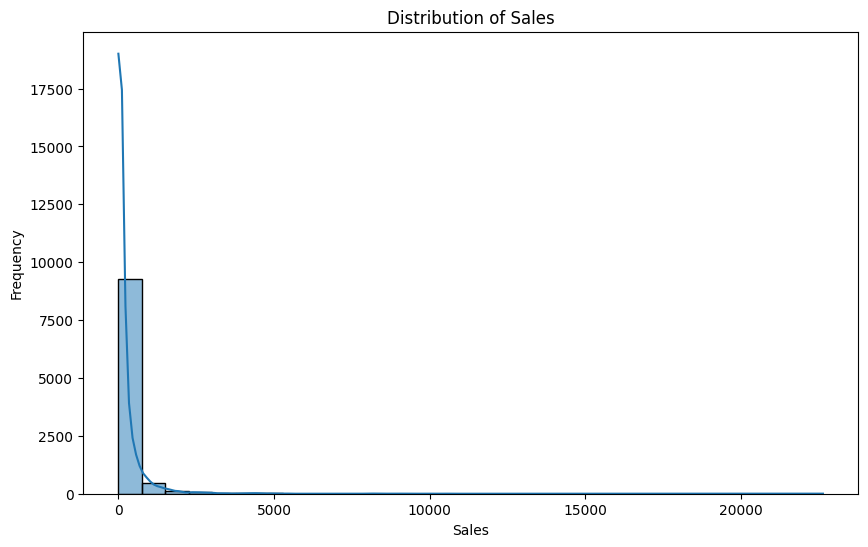

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [93]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")
df["Quarter"] = df["Order Date"].dt.to_period("Q")

df[["Order Date", "Year", "Month", "Quarter"]].head()

,Order Date,Year,Month,Quarter
0,2016-11-08,2016,2016-11,2016Q4
1,2016-11-08,2016,2016-11,2016Q4
2,2016-06-12,2016,2016-06,2016Q2
3,2015-10-11,2015,2015-10,2015Q4
4,2015-10-11,2015,2015-10,2015Q4


In [94]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.head()

,Sales
Month,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


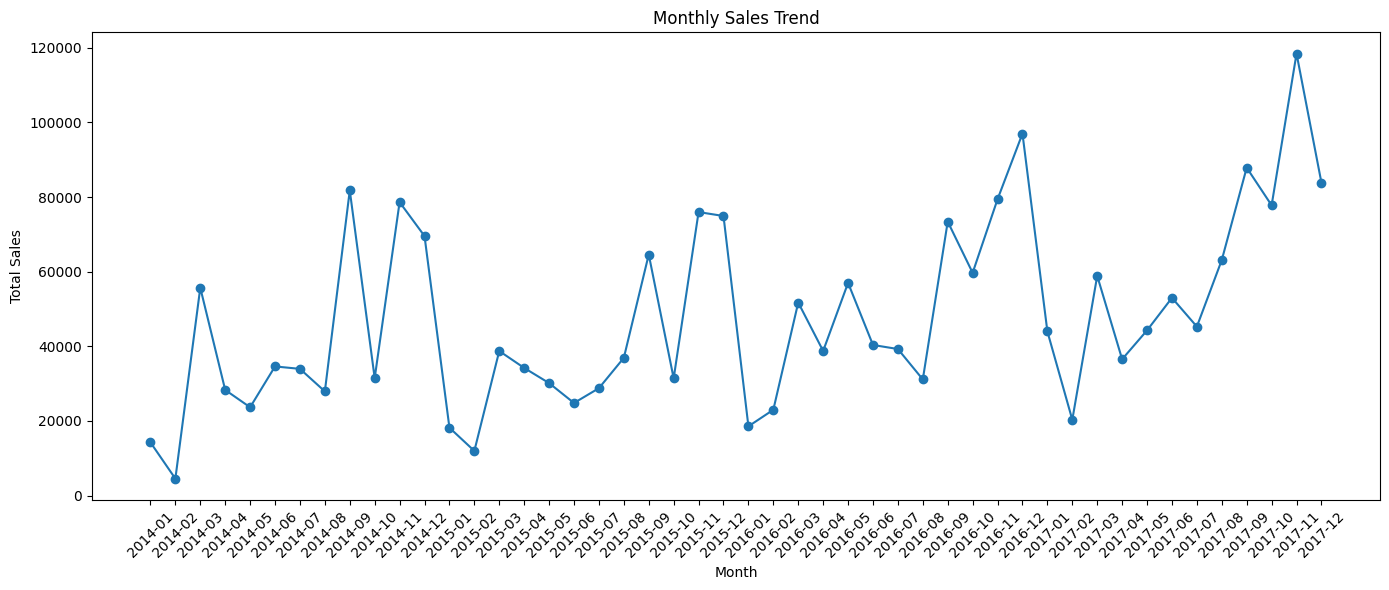

In [95]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [96]:
quarterly_sales = df.groupby("Quarter")["Sales"].sum()

quarterly_sales

,Sales
Quarter,
2014Q1,74447.7960
2014Q2,86538.7596
2014Q3,143633.2123
2014Q4,179627.7302
2015Q1,68851.7386
2015Q2,89124.1870
2015Q3,130259.5752
2015Q4,182297.0082
2016Q1,93237.1810


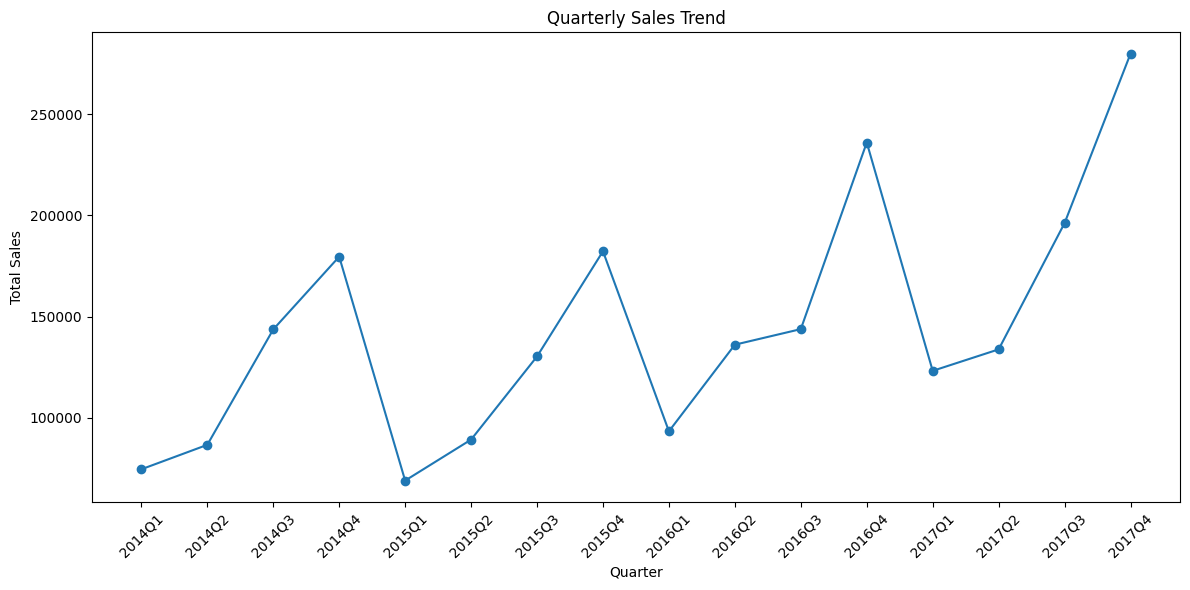

In [97]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [98]:
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", round(highest_month_sales, 2))

print("\nLowest Sales Month:", lowest_month)
print("Lowest Sales:", round(lowest_month_sales, 2))

Highest Sales Month: 2017-11
Highest Sales: 118447.82

Lowest Sales Month: 2014-02
Lowest Sales: 4519.89


In [99]:
segment_counts = df["Segment"].value_counts()

segment_counts

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


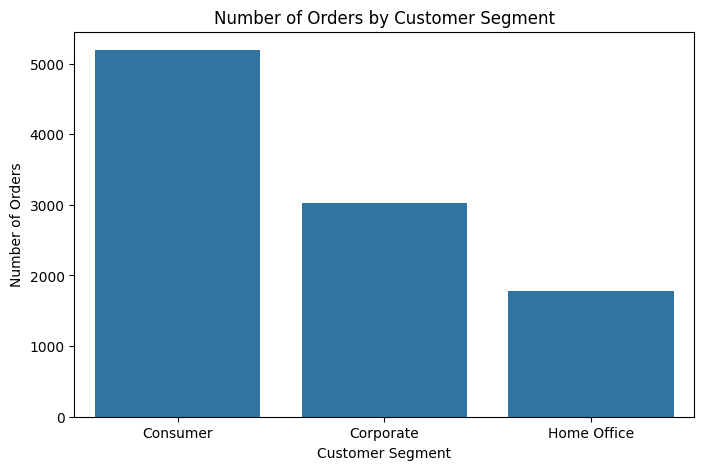

In [100]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Segment"
)

plt.title("Number of Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.show()

In [101]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


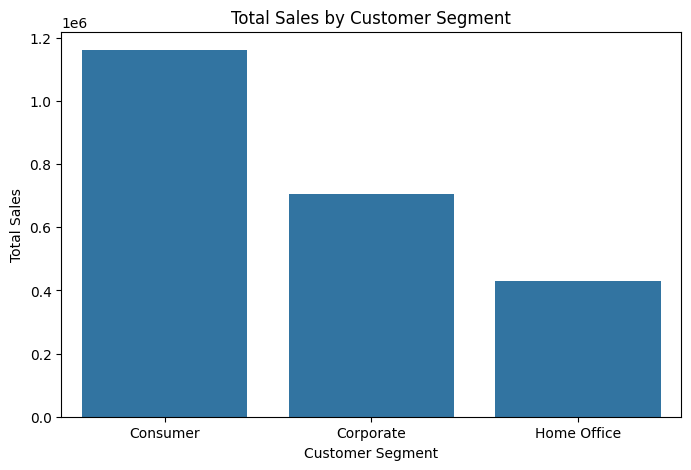

In [102]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

In [103]:
segment_avg_sales = (
    df.groupby("Segment")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

segment_avg_sales

,Sales
Segment,
Home Office,240.972041
Corporate,233.823300
Consumer,223.733644


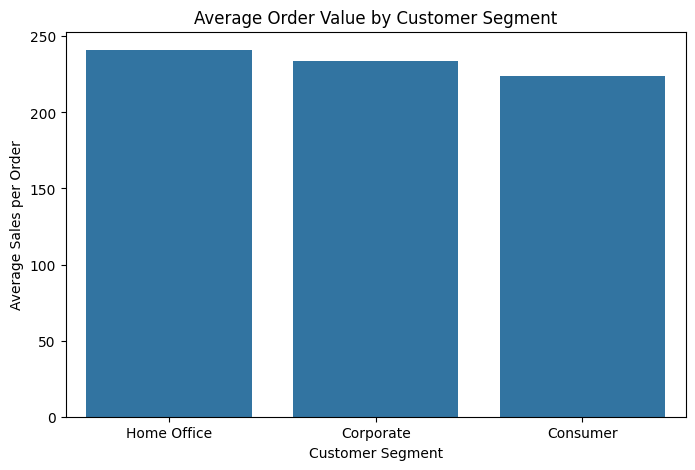

In [104]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_avg_sales.index,
    y=segment_avg_sales.values
)

plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales per Order")

plt.show()

In [105]:
unique_customers = df["Customer ID"].nunique()

print("Total Unique Customers:", unique_customers)

Total Unique Customers: 793


In [106]:
top_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,,Sales
Customer ID,Customer Name,
SM-20320,Sean Miller,25043.050
TC-20980,Tamara Chand,19052.218
RB-19360,Raymond Buch,15117.339
TA-21385,Tom Ashbrook,14595.620
AB-10105,Adrian Barton,14473.571
KL-16645,Ken Lonsdale,14175.229
SC-20095,Sanjit Chand,14142.334
HL-15040,Hunter Lopez,12873.298
SE-20110,Sanjit Engle,12209.438


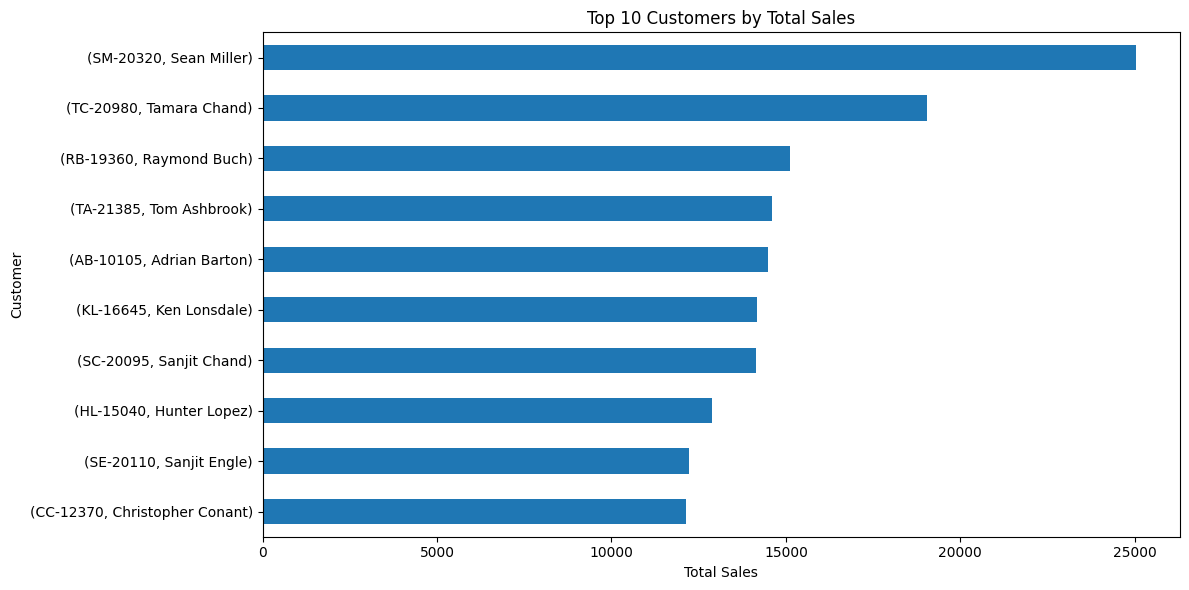

In [107]:
plt.figure(figsize=(12, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [108]:
customer_frequency = (
    df.groupby("Customer ID")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

customer_frequency

,Order ID
Customer ID,
EP-13915,17
SH-19975,13
NS-18640,13
PG-18820,13
ZC-21910,13
EA-14035,13
JE-15745,13
CK-12205,13
AH-10690,12


In [109]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


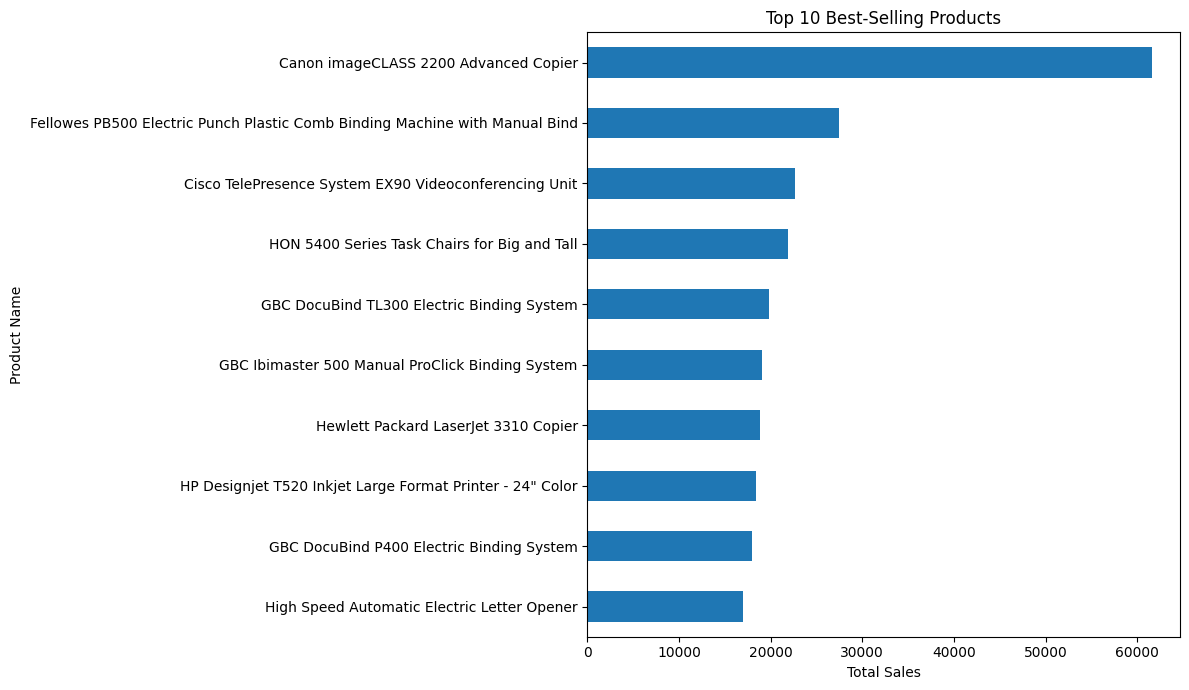

In [110]:
plt.figure(figsize=(12, 7))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [111]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


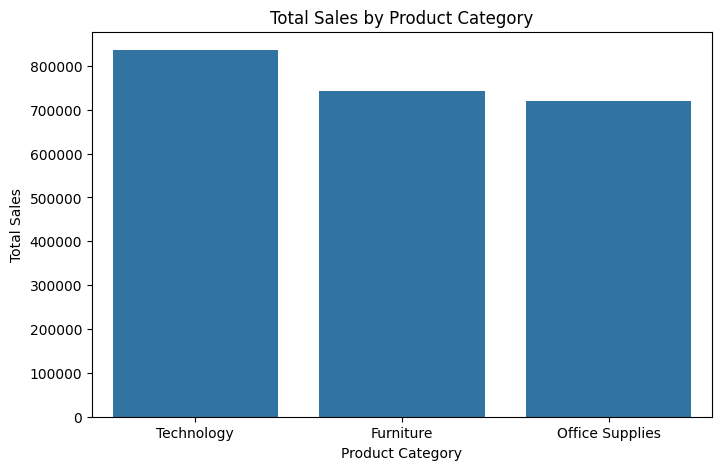

In [112]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

In [113]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


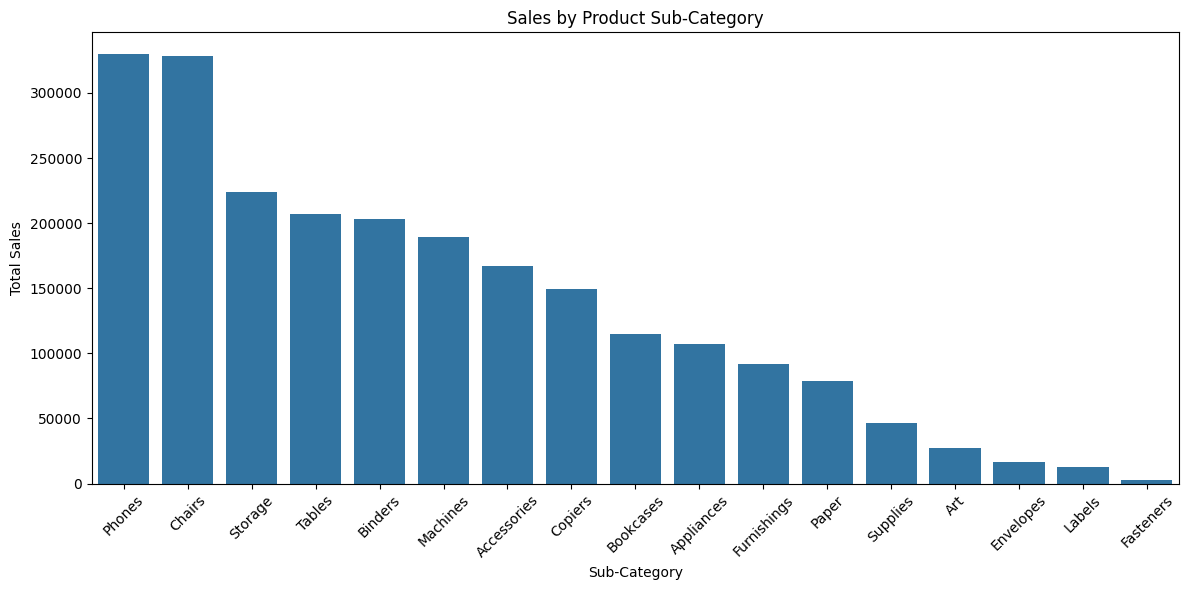

In [114]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=subcategory_sales.index,
    y=subcategory_sales.values
)

plt.title("Sales by Product Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [115]:
category_quantity = (
    df.groupby("Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

category_quantity

,Quantity
Category,
Office Supplies,22906
Furniture,8028
Technology,6939


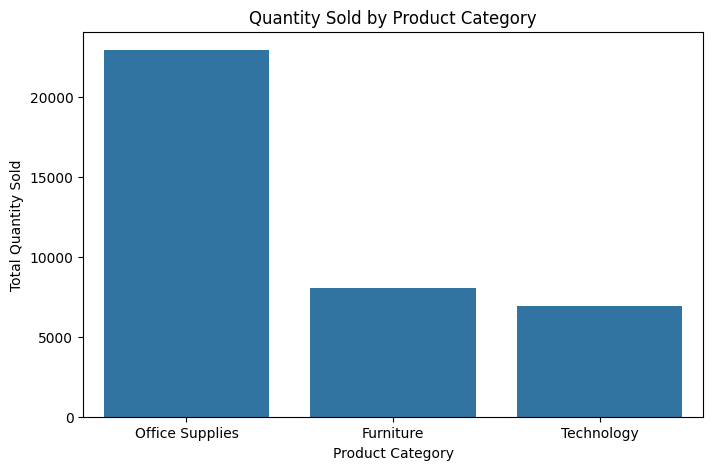

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.show()

In [117]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


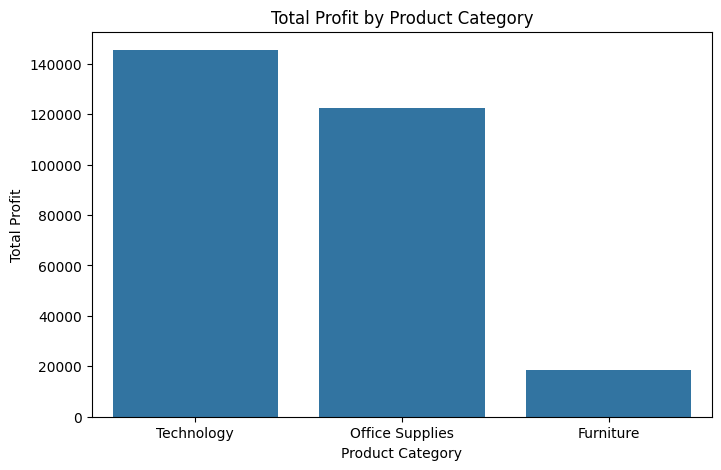

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.show()

In [119]:
category_performance = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity
Category,,,
Technology,836154.03,145454.95,6939
Furniture,741999.80,18451.27,8028
Office Supplies,719047.03,122490.80,22906


In [120]:
category_performance["Profit_Margin_%"] = (
    category_performance["Total_Profit"] /
    category_performance["Total_Sales"]
) * 100

category_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Category,,,,
Technology,836154.03,145454.95,6939,17.40
Furniture,741999.80,18451.27,8028,2.49
Office Supplies,719047.03,122490.80,22906,17.04


In [121]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


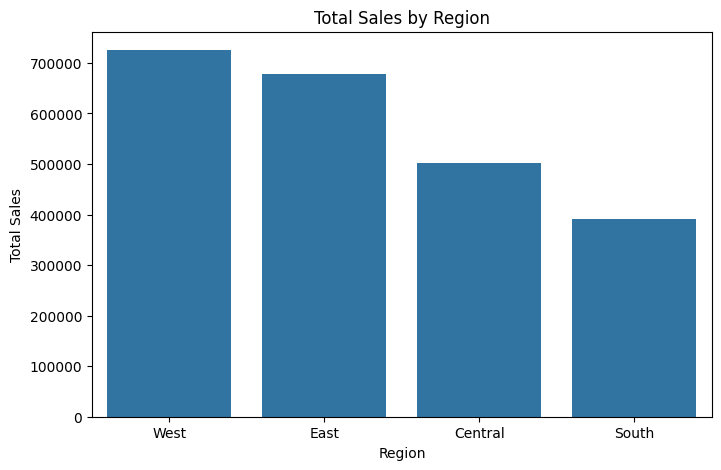

In [122]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [123]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


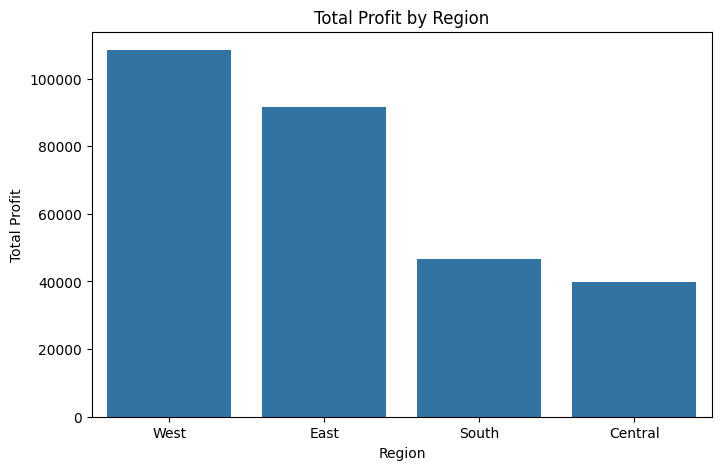

In [124]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

In [125]:
region_performance = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
)

region_performance["Profit_Margin_%"] = (
    region_performance["Total_Profit"] /
    region_performance["Total_Sales"]
) * 100

region_performance.sort_values(
    "Total_Sales",
    ascending=False
).round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Profit_Margin_%
Region,,,,,
West,725457.82,108418.45,12266,1611,14.94
East,678781.24,91522.78,10618,1401,13.48
Central,501239.89,39706.36,8780,1175,7.92
South,391721.90,46749.43,6209,822,11.93


In [126]:
state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_sales

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


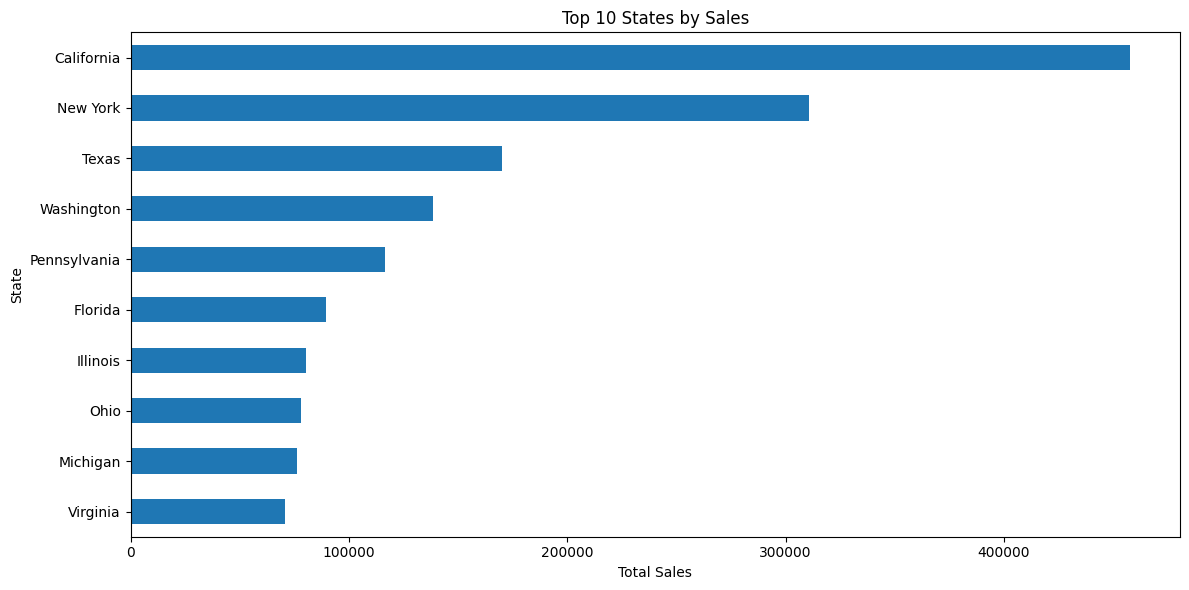

In [127]:
plt.figure(figsize=(12, 6))

state_sales.sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.tight_layout()
plt.show()

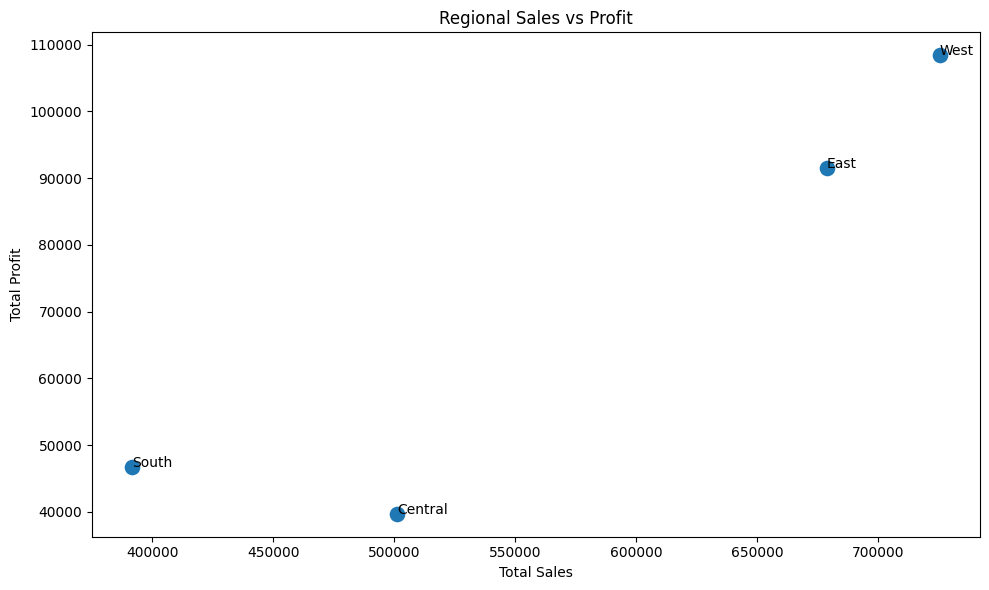

In [128]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=region_performance,
    x="Total_Sales",
    y="Total_Profit",
    s=150
)

for region in region_performance.index:
    plt.annotate(
        region,
        (
            region_performance.loc[region, "Total_Sales"],
            region_performance.loc[region, "Total_Profit"]
        )
    )

plt.title("Regional Sales vs Profit")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [129]:
correlation_data = df[
    ["Sales", "Quantity", "Discount", "Profit"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


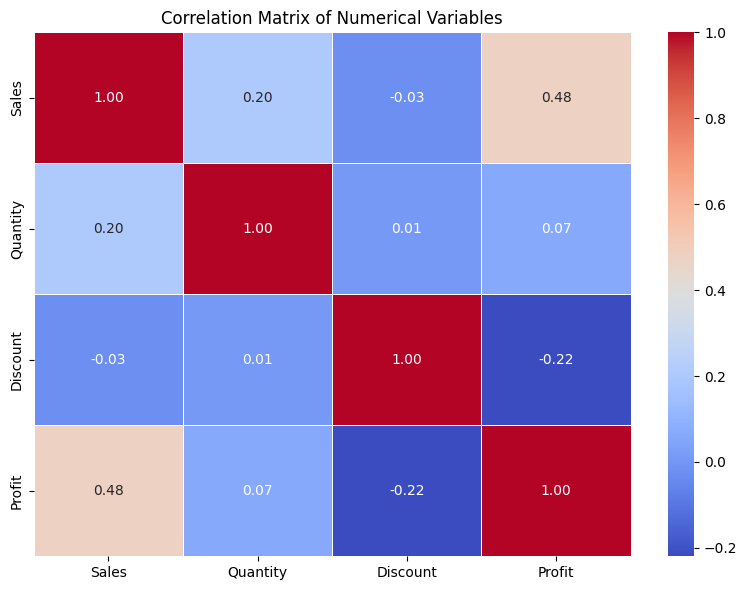

In [130]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

plt.show()


In [131]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) !=
    corr_pairs.index.get_level_values(1)
]

corr_pairs.abs().sort_values(ascending=False).head(10)

,,0
Sales,Profit,0.479064
Profit,Sales,0.479064
Discount,Profit,0.219487
Profit,Discount,0.219487
Sales,Quantity,0.200795
Quantity,Sales,0.200795
Profit,Quantity,0.066253
Quantity,Profit,0.066253
Sales,Discount,0.028190
Discount,Sales,0.028190


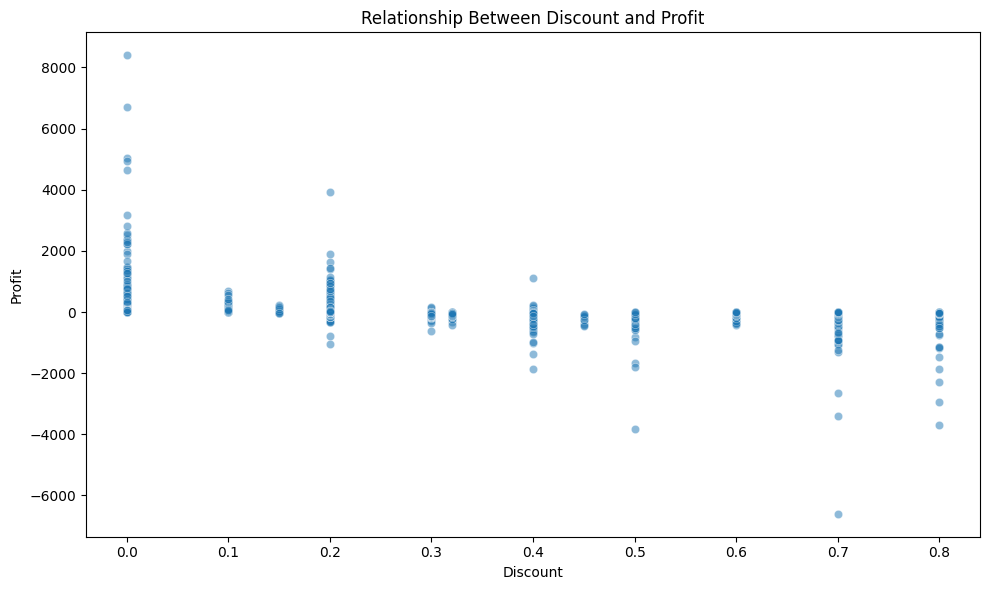

In [132]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [133]:
discount_profit = (
    df.groupby("Discount")["Profit"]
      .agg(["mean", "sum", "count"])
      .round(2)
)

discount_profit

,mean,sum,count
Discount,,,
0.00,66.90,320987.60,4798
0.10,96.06,9029.18,94
0.15,27.29,1418.99,52
0.20,24.70,90337.31,3657
0.30,-45.68,-10369.28,227
0.32,-88.56,-2391.14,27
0.40,-111.93,-23057.05,206
0.45,-226.65,-2493.11,11
0.50,-310.70,-20506.43,66


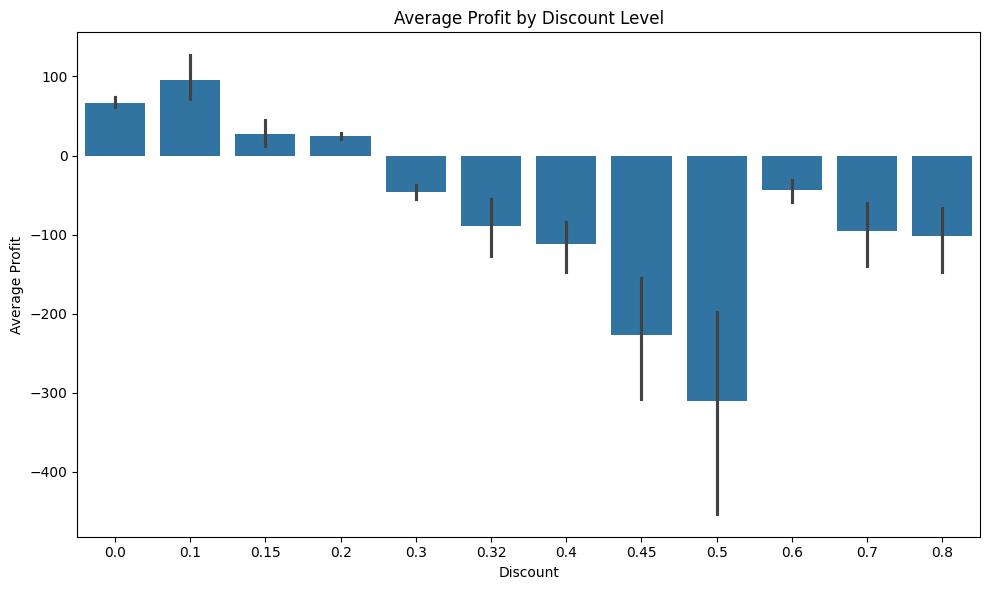

In [134]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()

In [135]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

overall_profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Overall Profit Margin: 12.47 %


In [136]:
kpi_summary = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Quantity Sold": df["Quantity"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Unique Customers": df["Customer ID"].nunique(),
    "Average Order Value": df["Sales"].mean(),
    "Overall Profit Margin (%)": (df["Profit"].sum() / df["Sales"].sum()) * 100
}

kpi_summary
kpi_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["Metric", "Value"]
)

kpi_df.round(2)


,Metric,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Total Quantity Sold,37873.00
3,Total Orders,5009.00
4,Unique Customers,793.00
5,Average Order Value,229.86
6,Overall Profit Margin (%),12.47


In [137]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Best-Selling Category:", best_category)
print("Sales:", round(best_category_sales, 2))

Best-Selling Category: Technology
Sales: 836154.03


In [138]:
best_profit_category = category_profit.idxmax()
best_profit = category_profit.max()

print("Most Profitable Category:", best_profit_category)
print("Profit:", round(best_profit, 2))


Most Profitable Category: Technology
Profit: 145454.95


In [139]:
best_segment = segment_sales.idxmax()
best_segment_sales = segment_sales.max()

print("Highest-Sales Customer Segment:", best_segment)
print("Sales:", round(best_segment_sales, 2))
best_avg_segment = segment_avg_sales.idxmax()

print("Highest Average Order Value Segment:", best_avg_segment)
print(
    "Average Order Value:",
    round(segment_avg_sales.max(), 2)
)

Highest-Sales Customer Segment: Consumer
Sales: 1161401.34
Highest Average Order Value Segment: Home Office
Average Order Value: 240.97


In [140]:
best_region = region_sales.idxmax()

print("Highest-Sales Region:", best_region)
print(
    "Sales:",
    round(region_sales.max(), 2)
)
best_profit_region = region_profit.idxmax()

print("Most Profitable Region:", best_profit_region)
print(
    "Profit:",
    round(region_profit.max(), 2)
)

Highest-Sales Region: West
Sales: 725457.82
Most Profitable Region: West
Profit: 108418.45


In [141]:
best_product = top_products.idxmax()
best_product_sales = top_products.max()

print("Top Product:", best_product)
print("Sales:", round(best_product_sales, 2))

Top Product: Canon imageCLASS 2200 Advanced Copier
Sales: 61599.82


In [142]:
insights = pd.DataFrame({
    "Area": [
        "Overall Sales",
        "Overall Profit",
        "Best Category",
        "Best Customer Segment",
        "Best Region",
        "Top Product",
        "Highest Sales Month"
    ],
    "Finding": [
        f"{df['Sales'].sum():,.2f}",
        f"{df['Profit'].sum():,.2f}",
        best_category,
        best_segment,
        best_region,
        best_product,
        str(highest_month)
    ]
})

insights

,Area,Finding
0,Overall Sales,"2,297,200.86"
1,Overall Profit,"286,397.02"
2,Best Category,Technology
3,Best Customer Segment,Consumer
4,Best Region,West
5,Top Product,Canon imageCLASS 2200 Advanced Copier
6,Highest Sales Month,2017-11


Now let's create your final recommendations

Since we have your actual results, add a Text/Markdown cell after the insights table:

# Business Recommendations

Based on the exploratory analysis of the Superstore dataset, the following recommendations can be made:

### 1. Prioritize the Technology Category

Technology is the highest-performing product category by sales. The company should maintain sufficient inventory of high-demand technology products and use targeted promotions to capitalize on continued demand.

### 2. Strengthen Consumer Segment Retention

The Consumer segment generates the highest sales among the customer segments. The company should focus on customer retention through loyalty programs, personalized offers, and targeted marketing campaigns.

### 3. Focus on the Western Region

The West region generates the highest sales among the analyzed regions. The company should strengthen its presence in this market while studying the strategies that contribute to its strong performance.

### 4. Promote High-Performing Products

The Canon imageCLASS 2200 Advanced Copier is the top product by total sales. The company should ensure consistent availability of high-performing products and consider cross-selling complementary products.

### 5. Prepare for Peak Sales Periods

November 2017 recorded the highest monthly sales in the analyzed period. The company should prepare inventory, marketing cam

